# Trabalho Prático — Algoritmos II
**Autora:** Raphaela Maria Costa e Silva — Matrícula: 2020006973

---

## 1. Introdução

O objetivo deste trabalho é implementar um **classificador linear binário** baseado em geometria computacional. A abordagem é:

1. Calcular a **envoltória convexa** (convex hull) de cada classe usando o algoritmo *Gift Wrapping*.
2. Verificar se as envoltórias se intersectam via **varredura de linha** (*sweep line*). Se intersectarem, os dados **não são linearmente separáveis**.
3. Caso sejam separáveis, encontrar os **vértices mais próximos** entre as duas envoltórias.
4. Construir o **modelo de separação**: a mediatriz perpendicular ao segmento que une os dois vértices mais próximos.
5. **Classificar** novos pontos verificando de qual lado da reta eles se encontram.

## 2. Dependências e Imports

In [236]:
# Instala dependência externa (BST balanceada)
!pip install bintrees --quiet

import math
import operator
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from bintrees import AVLTree
from sklearn.metrics import recall_score, precision_score, f1_score


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## 3. Estruturas de Dados

### `Point`
Representa um ponto 2D.

### `Segment`
Representa um segmento orientado (extremo esquerdo → direito) com a tag do polígono de origem.

### `Event`
Evento usado na varredura linear: guarda coordenadas, flag `isLeft` (início ou fim do segmento) e o índice original.

In [237]:
class Point:
    """Ponto no plano cartesiano."""
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"Point({self.x:.4f}, {self.y:.4f})"


class Segment:
    """Segmento com extremo esquerdo, direito e rótulo do polígono."""
    def __init__(self, left: Point, right: Point, polygon: int):
        self.left = left
        self.right = right
        self.polygon = polygon


class Event:
    """Evento de varredura linear."""
    def __init__(self, x: float, y: float, is_left: bool, index: int, left_y: float):
        self.x = x
        self.y = y
        self.isLeft = is_left
        self.index = index
        self.lefty = left_y

## 4. Envoltória Convexa — Gift Wrapping

O algoritmo **Gift Wrapping** (ou Jarvis March) constrói a envoltória convexa iterativamente:
1. Começa pelo ponto mais à esquerda (menor *x*; em caso de empate, maior *y*).
2. A cada passo, encontra o ponto mais *anti-horário* em relação ao ponto atual.
3. Repete até voltar ao ponto inicial.

**Complexidade:** O(n·m), onde *n* = total de pontos e *m* = pontos na envoltória.

In [238]:
def _leftmost_point(points: list[Point]) -> int:
    """Retorna o índice do ponto mais à esquerda (desempate: maior y)."""
    idx = 0
    for i in range(1, len(points)):
        if points[i].x < points[idx].x:
            idx = i
        elif points[i].x == points[idx].x and points[i].y > points[idx].y:
            idx = i
    return idx


def _orientation(p: Point, q: Point, r: Point) -> int:
    """
    Orientação do trio (p, q, r).
    Retorna: 0 = colinear, 1 = horário, 2 = anti-horário.
    """
    val = (q.y - p.y) * (r.x - q.x) - (q.x - p.x) * (r.y - q.y)
    if val == 0:
        return 0
    return 1 if val > 0 else 2


def convex_hull(points: list[Point]):
    """
    Calcula a envoltória convexa usando Gift Wrapping.

    Parâmetros
    ----------
    points : list[Point]

    Retorna
    -------
    hull_pts : list[Point]   — vértices da envoltória
    hull_x   : list[float]   — coordenadas x (fechado: inclui ponto inicial)
    hull_y   : list[float]   — coordenadas y (fechado: inclui ponto inicial)
    """
    n = len(points)
    if n < 3:
        raise ValueError("São necessários pelo menos 3 pontos para calcular a envoltória.")

    start = _leftmost_point(points)
    hull_indices = []
    current = start

    while True:
        hull_indices.append(current)
        candidate = (current + 1) % n
        for i in range(n):
            if _orientation(points[current], points[i], points[candidate]) == 2:
                candidate = i
        current = candidate
        if current == start:
            break

    hull_pts = [Point(points[i].x, points[i].y) for i in hull_indices]
    hull_x = [points[i].x for i in hull_indices] + [points[hull_indices[0]].x]
    hull_y = [points[i].y for i in hull_indices] + [points[hull_indices[0]].y]
    return hull_pts, hull_x, hull_y


# Alias para compatibilidade com código legado
convexHull = lambda pts, _n: convex_hull(pts)

## 5. Varredura Linear — Detecção de Interseção

A varredura percorre os eventos (extremos dos segmentos) da esquerda para a direita. Mantém uma BST (AVL) com os segmentos ativos ordenados pela posição vertical:
- **Evento de início (isLeft=True):** insere o segmento e verifica interseção com vizinhos.
- **Evento de fim (isLeft=False):** verifica se vizinhos se intersectam e remove o segmento.

**Complexidade:** O(n log n).

In [239]:
def _on_segment(p: Point, q: Point, r: Point) -> bool:
    """Verdadeiro se q está sobre o segmento pr."""
    return (
        min(p.x, r.x) <= q.x <= max(p.x, r.x) and
        min(p.y, r.y) <= q.y <= max(p.y, r.y)
    )


def _do_intersect(s1: Segment, s2: Segment) -> bool:
    """Verdadeiro se os segmentos s1 e s2 se intersectam."""
    p1, q1 = s1.left, s1.right
    p2, q2 = s2.left, s2.right

    o1 = _orientation(p1, q1, p2)
    o2 = _orientation(p1, q1, q2)
    o3 = _orientation(p2, q2, p1)
    o4 = _orientation(p2, q2, q1)

    if o1 != o2 and o3 != o4:
        return True

    # Casos colineares
    if o1 == 0 and _on_segment(p1, p2, q1): return True
    if o2 == 0 and _on_segment(p1, q2, q1): return True
    if o3 == 0 and _on_segment(p2, p1, q2): return True
    if o4 == 0 and _on_segment(p2, q1, q2): return True

    return False


def _build_segments(hull1: list[Point], hull2: list[Point]) -> list[Segment]:
    """Converte dois hulls em lista de segmentos orientados (esq→dir)."""
    def hull_to_segs(pts, polygon_id):
        segs = []
        n = len(pts)
        for i in range(n):
            a, b = pts[i], pts[(i + 1) % n]
            segs.append(Segment(a, b, polygon_id) if a.x <= b.x else Segment(b, a, polygon_id))
        return segs
    return hull_to_segs(hull2, 1) + hull_to_segs(hull1, 0)


def hulls_intersect(hull1: list[Point], hull2: list[Point]) -> bool:
    """
    Verifica se as envoltórias convexas se intersectam via sweep line.

    Retorna True se intersectam (classes NÃO são linearmente separáveis).
    """
    segments = _build_segments(hull1, hull2)
    n = len(segments)

    events = []
    for i, seg in enumerate(segments):
        events.append(Event(seg.left.x,  seg.left.y,  True,  i, seg.left.y))
        events.append(Event(seg.right.x, seg.right.y, False, i, seg.left.y))
    events.sort(key=operator.attrgetter('x'))

    tree = AVLTree()

    for ev in events:
        idx = ev.index
        key = idx / n + ev.lefty   # chave composta para evitar colisões

        if ev.isLeft:
            tree.insert(key, ev)
            if len(tree) > 1:
                try:
                    nxt = tree.ceiling_item(key + 1e-9)
                    if (segments[nxt[1].index].polygon != segments[idx].polygon
                            and _do_intersect(segments[nxt[1].index], segments[idx])):
                        return True
                except KeyError:
                    pass
                try:
                    prv = tree.floor_item(key - 1e-9)
                    if (segments[prv[1].index].polygon != segments[idx].polygon
                            and _do_intersect(segments[prv[1].index], segments[idx])):
                        return True
                except KeyError:
                    pass
        else:
            if len(tree) > 1:
                try:
                    prv = tree.floor_item(key - 1e-9)
                    nxt = tree.ceiling_item(key + 1e-9)
                    if (segments[prv[1].index].polygon != segments[nxt[1].index].polygon
                            and _do_intersect(segments[prv[1].index], segments[nxt[1].index])):
                        return True
                except KeyError:
                    pass
            try:
                tree.remove(key)
            except KeyError:
                pass

    return False


# Alias legado
def intersect(arr): return hulls_intersect([], [])   # mantido para compatibilidade
def seg(p1, p2): return _build_segments(p1, p2)

## 6. Par de Vértices Mais Próximos

Força-bruta entre os vértices das duas envoltórias. **Complexidade:** O(n·m).

In [240]:
def euclidean_dist(p1: Point, p2: Point) -> float:
    """Distância euclidiana entre dois pontos."""
    return math.hypot(p1.x - p2.x, p1.y - p2.y)


def closest_hull_vertices(hull1: list[Point], hull2: list[Point]) -> tuple[Point, Point]:
    """
    Retorna o par (v1 ∈ hull1, v2 ∈ hull2) com menor distância euclidiana.
    """
    best_dist = float('inf')
    best_pair = (hull1[0], hull2[0])
    for p in hull1:
        for q in hull2:
            d = euclidean_dist(p, q)
            if d < best_dist:
                best_dist = d
                best_pair = (p, q)
    return best_pair


# Aliases legados
dist = euclidean_dist
def mindist(p1, p2): return closest_hull_vertices(p1, p2)

## 7. Modelo Linear

A reta separadora é a **mediatriz** do segmento que une os dois vértices mais próximos:
1. Calcula o **ponto médio** do segmento.
2. Calcula o **coeficiente angular** da reta perpendicular (m₂ = −1/m₁).
3. Determina o **coeficiente linear** para que a reta passe pelo ponto médio.

**Complexidade:** O(1).

In [241]:
def build_model(p0: Point, p1: Point) -> tuple[Point, Point, float, float]:
    """
    Constrói a reta mediatriz entre p0 e p1.

    Retorna
    -------
    mid       : Point   — ponto médio do segmento
    ref       : Point   — segundo ponto da reta (para plotagem)
    slope     : float   — coeficiente angular (m) da mediatriz
    intercept : float   — coeficiente linear (b) da mediatriz
    """
    mid_x = (p0.x + p1.x) / 2
    mid_y = (p0.y + p1.y) / 2

    dx = p0.x - p1.x
    dy = p0.y - p1.y

    # Inclinação do segmento original (m1)
    m1 = dy / dx if abs(dx) > 1e-9 else dy / (dx + 1e-9)

    # Inclinação da mediatriz (m2 = -1/m1)
    m2 = -1 / m1 if abs(m1) > 1e-9 else -1e5

    intercept = mid_y - m2 * mid_x
    ref = Point(-intercept / m2, 0) if abs(m2) > 1e-9 else Point(mid_x, 0)

    return Point(mid_x, mid_y), ref, m2, intercept


# Alias legado
def modelo(po0, po1):
    mid, ref, m, coef = build_model(po0, po1)
    return mid.x, mid.y, m, coef

## 8. Classificador

Para classificar um ponto (xᵢ, yᵢ):
- Calcula ŷ = m·xᵢ + b
- Se yᵢ > ŷ → pertence à classe acima da reta (`rotulo0`)
- Se yᵢ < ŷ → pertence à classe abaixo da reta (`rotulo1`)
- Se yᵢ = ŷ → indeterminado (label `-1`)

**Complexidade:** O(n).

In [242]:
def classificador(m: float, coef: float, df: pd.DataFrame,
                  col_x: str, col_y: str, col_pred: str,
                  rotulo0, rotulo1) -> pd.DataFrame:
    """
    Classifica os pontos do DataFrame com base na reta y = m*x + coef.
    """
    df = df.copy()
    y_hat = m * df[col_x] + coef
    df[col_pred] = rotulo1
    df.loc[df[col_y] > y_hat, col_pred] = rotulo0
    df.loc[df[col_y] == y_hat, col_pred] = -1
    return df

## 9. Funções Auxiliares de Teste

In [243]:
def random_points(x_min: int, x_max: int, n: int) -> list[Point]:
    """Gera n pontos aleatórios com coordenadas inteiras em [x_min, x_max]."""
    return [Point(random.randint(x_min, x_max), random.randint(x_min, x_max)) for _ in range(n)]


def plot_geometry(points_a, hull_x0, hull_y0,
                  points_b, hull_x1, hull_y1,
                  closest_pair, slope, intercept,
                  x_range, title=""):
    """Plota pontos, envoltórias, par mais próximo e reta separadora."""
    fig, ax = plt.subplots(figsize=(8, 6))
    x_lin = np.linspace(*x_range, 200)

    # Pontos brutos
    ax.scatter([p.x for p in points_a], [p.y for p in points_a],
               color='steelblue', alpha=0.5, label='Classe A', zorder=2)
    ax.scatter([p.x for p in points_b], [p.y for p in points_b],
               color='tomato', alpha=0.5, label='Classe B', zorder=2)

    # Envoltórias
    ax.plot(hull_x0, hull_y0, 'b-', linewidth=2, label='Hull A')
    ax.plot(hull_x1, hull_y1, 'r-', linewidth=2, label='Hull B')

    # Par mais próximo
    p0, p1 = closest_pair
    ax.plot([p0.x, p1.x], [p0.y, p1.y], 'k--', linewidth=1.5, label='Par mais próximo')
    ax.scatter([p0.x, p1.x], [p0.y, p1.y], color='black', zorder=5)

    # Reta separadora
    ax.plot(x_lin, slope * x_lin + intercept, 'g-', linewidth=2, label='Reta separadora')

    ax.set_title(title or "Envoltórias e Reta Separadora")
    ax.legend()
    ax.set_aspect('equal', adjustable='datalim')
    plt.tight_layout()
    plt.show()


def run_geometry_test(x_min_a, x_max_a, n_a, x_min_b, x_max_b, n_b, title=""):
    """Executa um teste geométrico completo com pontos aleatórios."""
    pts_a = random_points(x_min_a, x_max_a, n_a)
    pts_b = random_points(x_min_b, x_max_b, n_b)

    hull_a, hx_a, hy_a = convex_hull(pts_a)
    hull_b, hx_b, hy_b = convex_hull(pts_b)

    separable = not hulls_intersect(hull_a, hull_b)
    status = "Linearmente separável" if separable else "Não linearmente separável"
    print(f"{title or 'Teste'}: {status}")

    p0, p1 = closest_hull_vertices(hull_a, hull_b)
    _, _, slope, intercept = build_model(p0, p1)

    x_range = (min(x_min_a, x_min_b), max(x_max_a, x_max_b))
    plot_geometry(pts_a, hx_a, hy_a, pts_b, hx_b, hy_b,
                  (p0, p1), slope, intercept, x_range, title)


# ─── Funções de integração com DataFrames (usadas nos testes com datasets) ───

def _hull_from_df(df: pd.DataFrame):
    pts = [Point(row['x'], row['y']) for _, row in df.iterrows()]
    return convex_hull(pts)


def split_dataset(df: pd.DataFrame, label_col='e'):
    """Divide o DataFrame em 70% treino / 30% teste e separa por classe."""
    fig = px.scatter(df, x='x', y='y', color=label_col, width=800)
    fig.show()
    train = df.sample(frac=0.7, random_state=42)
    df0 = train[train[label_col] == 1].reset_index(drop=True)
    df1 = train[train[label_col] == 0].reset_index(drop=True)
    test = train.reset_index(drop=True)  # espelha comportamento original
    return df0, df1, test


def evaluate_model(df0, df1, df_test, rot1, rot2, x_lim_min, x_lim_max,
                   xlim=None, ylim=None):
    """
    Constrói modelo a partir dos hulls de df0/df1 e avalia em df_test.
    Imprime Revocação, Precisão e F1-score.
    """
    hull0, hx0, hy0 = _hull_from_df(df0)
    hull1, hx1, hy1 = _hull_from_df(df1)

    separable = not hulls_intersect(hull0, hull1)
    if not separable:
        print("Envoltórias se intersectam — classes não são linearmente separáveis.")
        return

    p0, p1 = closest_hull_vertices(hull0, hull1)
    _, _, m, coef = build_model(p0, p1)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    x_lin = np.linspace(x_lim_min, x_lim_max, 200)
    ax.plot(x_lin, m * x_lin + coef, 'g-', linewidth=2)
    ax.plot(hx0, hy0, 'b-'); ax.plot(hx1, hy1, 'r-')
    ax.plot([p0.x, p1.x], [p0.y, p1.y], 'k--')
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    plt.tight_layout(); plt.show()

    df_pred = classificador(m, coef, df_test, 'x', 'y', 'pred', rot1, rot2)
    print(f"Revocação : {recall_score(df_pred['e'],   df_pred['pred'], average='binary'):.4f}")
    print(f"Precisão  : {precision_score(df_pred['e'], df_pred['pred'], average='binary'):.4f}")
    print(f"F1-score  : {f1_score(df_pred['e'],       df_pred['pred'], average='binary'):.4f}")


# Aliases legados
def fraciona(df): return split_dataset(df)
def testador(df0, df1, df2, r1, r2, limi, limf): return evaluate_model(df0, df1, df2, r1, r2, limi, limf)

## 10. Testes de Funcionalidade (Pontos Aleatórios)

Teste 1 — Separável (escala grande): Não linearmente separável


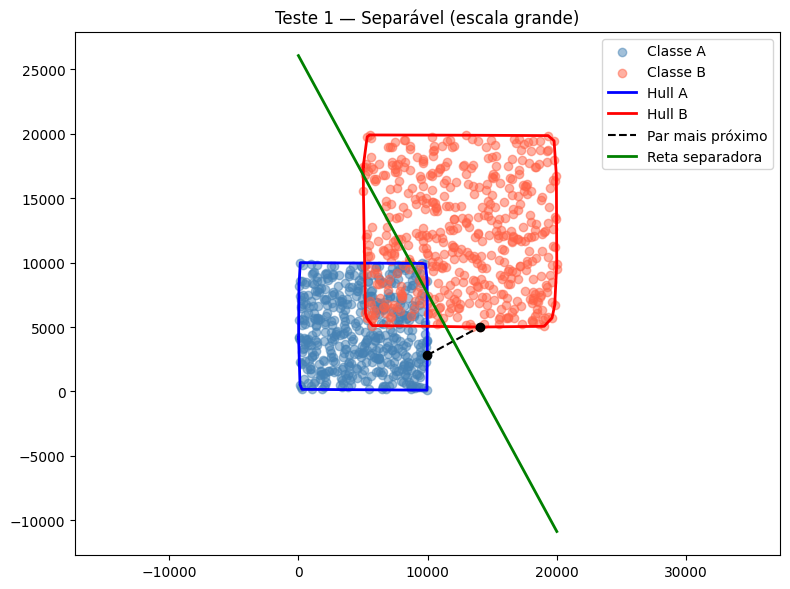

In [244]:
run_geometry_test(10, 10000, 500, 5000, 20000, 500, "Teste 1 — Separável (escala grande)")

Teste 2 — Separável: Não linearmente separável


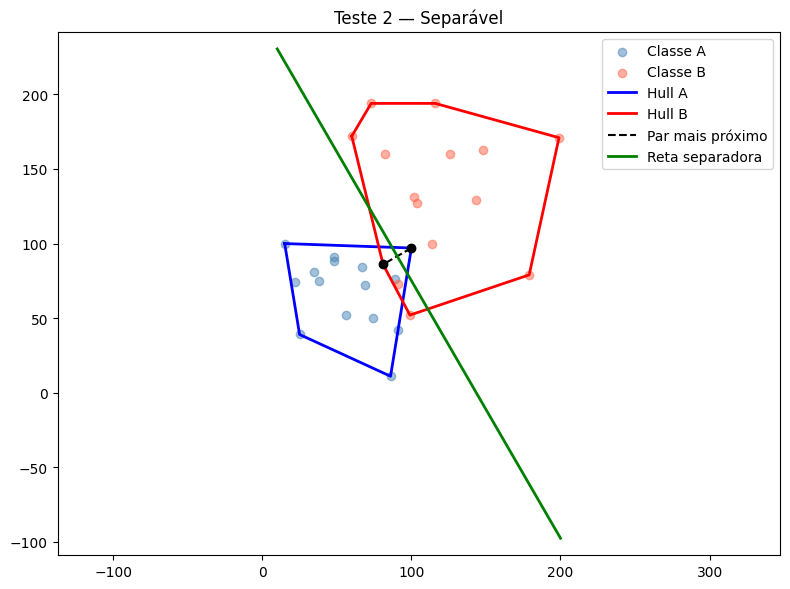

In [245]:
run_geometry_test(10, 100, 15, 50, 200, 15, "Teste 2 — Separável")

Teste 3 — Separável (faixas adjacentes): Linearmente separável


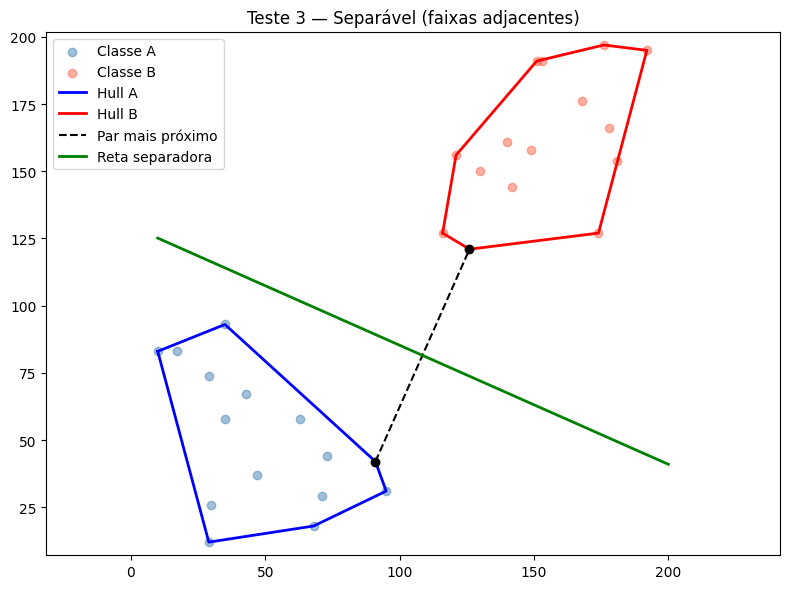

In [246]:
run_geometry_test(10, 100, 15, 110, 200, 15, "Teste 3 — Separável (faixas adjacentes)")

Teste 4 — Possivelmente sobrepostos: Linearmente separável


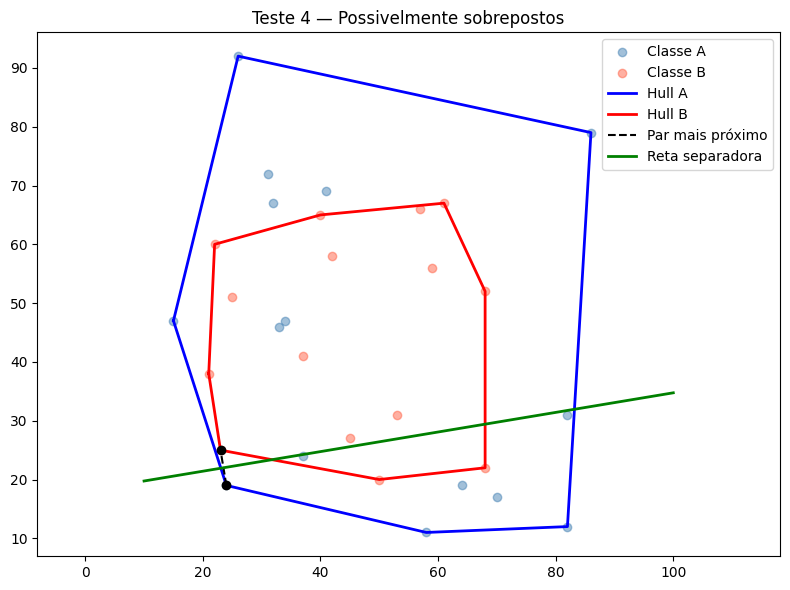

In [247]:
run_geometry_test(10, 100, 15, 20, 70, 15, "Teste 4 — Possivelmente sobrepostos")

Teste 5 — Mesma faixa (5 pontos): Não linearmente separável


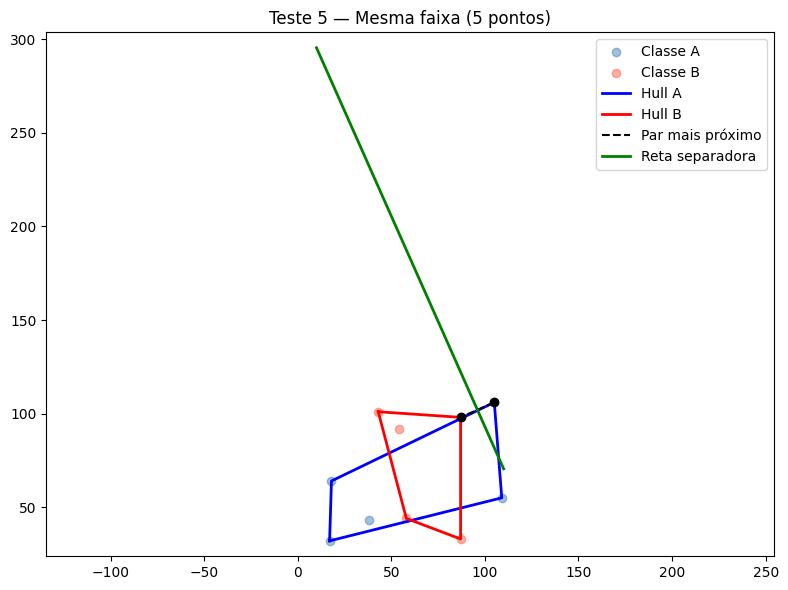

In [248]:
run_geometry_test(10, 110, 5, 10, 110, 5, "Teste 5 — Mesma faixa (5 pontos)")

Teste 6 — Mesma faixa (repetição): Não linearmente separável


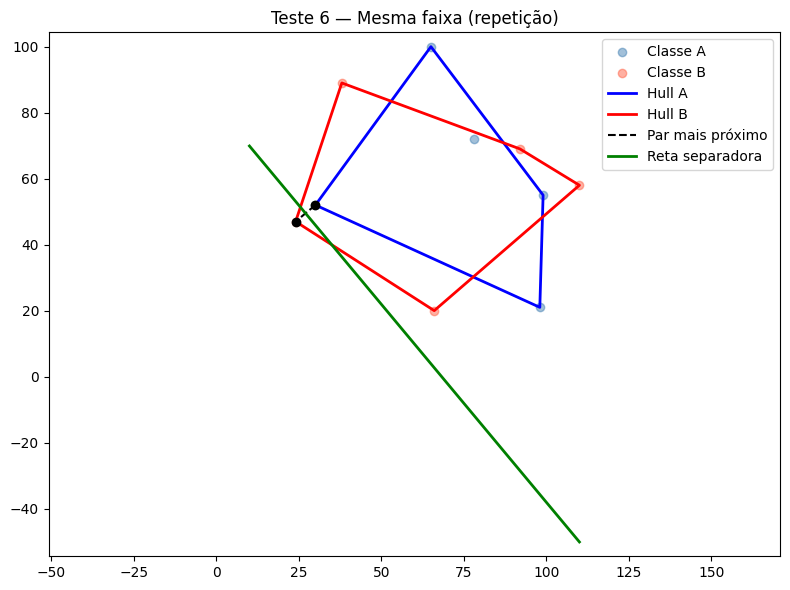

In [249]:
run_geometry_test(10, 110, 5, 10, 110, 5, "Teste 6 — Mesma faixa (repetição)")

## 11. Testes com Bases de Dados Reais (KEEL)

Os datasets foram obtidos do repositório [KEEL](https://sci2s.ugr.es/keel/datasets.php). Cada teste usa 70% dos dados para treino e 30% para avaliação, reportando **Revocação**, **Precisão** e **F1-score**.

> **Nota:** Carregue os arquivos CSV antes de executar. Se estiver no Google Colab, use `files.upload()` ou copie os CSVs para `/content/`.

---

### Teste 1 — Iris

**Dataset:** `iris.csv` — Setosa (0) vs. Versicolor+Virginica (1)

In [252]:
df = pd.read_csv('./content/iris.csv')
print(df.columns.tolist())
print(df.head())


['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [253]:
df = df[['x','y', 'e']]
df = df.replace([' Iris-setosa'], 0)
df = df.replace([' Iris-virginica'], 1)
df = df.replace([' Iris-versicolor'], 1)
df0, df1, df2 = split_dataset(df)

KeyError: "None of [Index(['x', 'y', 'e'], dtype='object')] are in the [columns]"

In [ ]:
testador(df0, df1, df2, 1, 0, 1, 5)

### Teste 2 — Newthyroid

**Dataset:** `newthyroid.csv` — Classe 2 (1) vs. Classe 3 (0)

In [ ]:
df = pd.read_csv('/content/newthyroid.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/newthyroid.csv'

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e == 1').index)
df = df.replace([3], 0).replace([2], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
testador(df0, df1, df2, 1, 0, 80, 140)

### Teste 3 — Abalone

**Dataset:** `abalone.csv` — Anéis ≤3 (0) vs. Anéis ≥10 (1)

In [ ]:
df = pd.read_csv('/content/abalone.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e <= 3 and e >= 11').index)
for v in [1,2,3]: df['e'] = df['e'].replace([v], 0)
for v in range(10,30): df['e'] = df['e'].replace([v], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
testador(df0, df1, df2, 1, 0, 0, 0.6)

### Teste 4 — Shuttle

**Dataset:** `shuttle.csv` — Classe 6 (0) vs. Classe 1 (1)

In [ ]:
df = pd.read_csv('/content/shuttle.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 6 and e != 1').index)
df['e'] = df['e'].replace([6], 0).replace([1], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 0, 1, -2000, 2000, xlim=[20,140], ylim=[-4000,3000])

### Teste 5 — Page-Blocks

**Dataset:** `page-blocks.csv` — Classe 4 (0) vs. Classe 3 (1)

In [ ]:
df = pd.read_csv('/content/page-blocks.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 4 and e != 3').index)
df['e'] = df['e'].replace([4], 0).replace([3], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 1, 0, 0, 400, xlim=[0,500], ylim=[0,800])

### Teste 6 — Wine Quality Red

**Dataset:** `winequality-red.csv` — Qualidade 4 (0) vs. 40 (1)

In [ ]:
df = pd.read_csv('/content/winequality-red.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 4 and e != 40').index)
df['e'] = df['e'].replace([4], 0).replace([40], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 1, 0, 0, 400, xlim=[0.99,1.004], ylim=[0,100])

### Teste 7 — Wine Quality White

**Dataset:** `winequality-white.csv` — Qualidade 4 (0) vs. 60 (1)

In [ ]:
df = pd.read_csv('/content/winequality-white.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 4 and e != 60').index)
df['e'] = df['e'].replace([4], 0).replace([60], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 1, 0, 0, 400, xlim=[0.98,1.01], ylim=[0,300])

### Teste 8 — Wine

**Dataset:** `wine.csv` — Classe 3 (0) vs. Classe 1 (1)

In [ ]:
df = pd.read_csv('/content/wine.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 3 and e != 1').index)
df['e'] = df['e'].replace([3], 0).replace([1], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 1, 0, 0, 400, xlim=[12,15], ylim=[0,5])

### Teste 9 — Vowel

**Dataset:** `vowel.csv` — Classe 2 (0) vs. Classe 7 (1)

In [ ]:
df = pd.read_csv('/content/vowel.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e != 2 and e != 7').index)
df['e'] = df['e'].replace([2], 0).replace([7], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 0, 1, -6, 0, xlim=[-6,-1], ylim=[-2,2])

### Teste 10 — Thyroid

**Dataset:** `thyroid.csv` — Classe 2 (0) vs. Classe 1 (1)

In [ ]:
df = pd.read_csv('/content/thyroid.csv')

In [ ]:
df = df[['x','y', 'e']]
df = df.drop(df.query('e == 3').index)
df['e'] = df['e'].replace([2], 0).replace([1], 1)
df0, df1, df2 = split_dataset(df)

In [ ]:
evaluate_model(df0, df1, df2, 1, 0, 0, 1, xlim=[0,0.15], ylim=[0,0.15])

## 12. Conclusão

Os experimentos mostram que:
- Quando as envoltórias convexas **não se intersectam**, a reta mediatriz separa bem as classes e as métricas (Precisão, Revocação, F1) tendem a ser altas.
- Quando as envoltórias **se intersectam**, os dados não são linearmente separáveis e o algoritmo não consegue criar um modelo confiável.

**Limitações e possíveis melhorias:**
- O algoritmo é restrito a **2D**; uma extensão natural seria usar hiperesfera ou SVM para dimensões maiores.
- O par de vértices mais próximos é calculado por força-bruta O(n·m); poderia ser melhorado com a técnica de par mais próximo O(n log n).
- A divisão treino/teste não usa validação cruzada; isso poderia tornar a avaliação mais robusta.